# Notebook 03: Benchmark, Model Training, Evaluation & Deployment

## Pipeline Overview
| Step | Description |
|------|-------------|
| **1. Setup** | Connect to Feature Store & pull train/val/test splits |
| **2. Benchmark** | Naïve Historical Volatility carry-forward heuristic |
| **3. ML Model** | XGBoost Regressor trained via SageMaker Estimator |
| **4. Evaluation** | RMSE, MAE, R² comparison: Benchmark vs XGBoost |
| **5. Deployment** | Real-Time SageMaker Endpoint with sample inference |

## Environment Setup & Data Loading

In [1]:
# ==============================================================================
# Notebook 03: Benchmark, ML Model Training, Evaluation & Deployment
# ==============================================================================
# Description:
# Pulls engineered features from S3 (written by Notebook 02), establishes a
# naïve benchmark, trains an XGBoost model via a SageMaker Estimator, evaluates
# both models side-by-side, and deploys the winner to a real-time endpoint.

!pip install -q xgboost scikit-learn pyathena

import pandas as pd
import numpy as np
import boto3
import sagemaker
import io
import os
import time
import json
import tarfile
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pyathena import connect
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import importlib, sagemaker as _sm
print(f"SageMaker SDK version: {_sm.__version__}")

# Session
try:
    from sagemaker.core.helper.session_helper import Session
except ImportError:
    from sagemaker import Session

_ti_paths = [
    'sagemaker.inputs',
    'sagemaker.session',
    'sagemaker.workflow.steps',
    'sagemaker',
]
TrainingInput = None
for _p in _ti_paths:
    try:
        TrainingInput = getattr(importlib.import_module(_p), 'TrainingInput')
        print(f"TrainingInput found in: {_p}")
        break
    except (ImportError, AttributeError):
        continue
if TrainingInput is None:
    raise ImportError("Could not locate TrainingInput in this SageMaker SDK. Run: import sagemaker; help(sagemaker) to inspect.")

# Dynamically locate XGBoost estimator
_xgb_paths = [
    ('sagemaker.xgboost',          'XGBoost'),
    ('sagemaker.xgboost.estimator','XGBoost'),
    ('sagemaker.estimator',        'Estimator'),
]
XGBoost = None
for _mod, _cls in _xgb_paths:
    try:
        XGBoost = getattr(importlib.import_module(_mod), _cls)
        print(f"XGBoost estimator found in: {_mod}.{_cls}")
        break
    except (ImportError, AttributeError):
        continue
if XGBoost is None:
    raise ImportError("Could not locate XGBoost estimator in this SageMaker SDK.")

# --- AWS Configuration (mirrors Notebook 02 pattern) ---
session = Session()
sagemaker_session = sagemaker.Session()
s3_client = boto3.client('s3')
sm_client = boto3.client('sagemaker')

# Reconstructing IAM role via STS (same fix as Notebook 02)
sts_client = boto3.client('sts')
caller_identity = sts_client.get_caller_identity()
caller_arn = caller_identity['Arn']
account_id = caller_identity['Account']

if "assumed-role" in caller_arn:
    role_name = caller_arn.split('/')[1]
    sagemaker_role = f"arn:aws:iam::{account_id}:role/{role_name}"
else:
    sagemaker_role = sagemaker.get_execution_role()

S3_BUCKET = session.default_bucket()
ATHENA_DB  = "quantamental_risk_db"
REGION     = boto3.Session().region_name
PREFIX     = "quantamental-platform"

# Athena connection (used to pull validation & test splits that were NOT ingested
# into the Feature Store — they live in S3 as raw CSVs from Notebook 01)
conn = connect(
    s3_staging_dir=f"s3://{S3_BUCKET}/athena-results/",
    region_name=REGION
)

FEATURE_COLS = ['Log_Return', 'EMA_5', 'EMA_20', 'Hist_Vol_5d', 'News_Sentiment_Score']
TARGET_COL   = 'Target_Fwd_Vol_5d'

print(f"Role  : {sagemaker_role}")
print(f"Bucket: {S3_BUCKET}")
print(f"Region: {REGION}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


SageMaker SDK version: 2.257.3
TrainingInput found in: sagemaker.inputs
XGBoost estimator found in: sagemaker.xgboost.XGBoost


Role  : arn:aws:iam::025891565789:role/LabRole
Bucket: sagemaker-us-east-1-025891565789
Region: us-east-1


In [2]:
# ==============================================================================
# 1b. Re-engineer Features from Athena
# ==============================================================================
# The Feature Store only ingested TRAIN data. For val/test we
# re-run the same feature engineering logic directly from the Athena tables.

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Replicateing the exact feature engineering from Eda and Feature Engineering."""
    dfs = []
    for ticker in df['Ticker'].unique():
        t = df[df['Ticker'] == ticker].copy().sort_values('Date')
        t['Log_Return']           = np.log(t['Close'] / t['Close'].shift(1))
        t['EMA_5']                = t['Log_Return'].ewm(span=5,  adjust=False).mean()
        t['EMA_20']               = t['Log_Return'].ewm(span=20, adjust=False).mean()
        t['Hist_Vol_5d']          = t['Log_Return'].rolling(window=5).std()
        t['Target_Fwd_Vol_5d']    = t['Log_Return'].rolling(window=5).std().shift(-5)
        t['News_Sentiment_Score'] = np.random.uniform(-1, 1, size=len(t))
        dfs.append(t)
    return pd.concat(dfs).dropna()


def query_split(split_table: str) -> pd.DataFrame:
    """Queries one of the Athena split tables and engineers features."""
    q = f"""
        SELECT "Date", "Open", "High", "Low", "Close", "Volume", "Ticker"
        FROM {ATHENA_DB}.{split_table}
        ORDER BY "Date" ASC
    """
    df = pd.read_sql(q, conn)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.drop_duplicates(subset=['Date', 'Ticker'])
    return engineer_features(df)


print("Loading TRAIN split from Athena...")
train_df = query_split("market_data_train")

# Creating Validation and test tables from raw csv stored in S3
def load_split_from_s3(split_name: str) -> pd.DataFrame:
    key = f"{PREFIX}/raw-data/quantitative/{split_name}/market_data.csv"
    obj = s3_client.get_object(Bucket=S3_BUCKET, Key=key)
    df  = pd.read_csv(io.BytesIO(obj['Body'].read()))
    df['Date'] = pd.to_datetime(df['Date'])
    return engineer_features(df)


print("Loading VALIDATION split from S3...")
val_df  = load_split_from_s3("validation")

print("Loading TEST split from S3...")
test_df = load_split_from_s3("test")

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f"\nShapes — Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Loading TRAIN split from Athena...


/tmp/ipykernel_1015/530038144.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


Loading VALIDATION split from S3...
Loading TEST split from S3...



Shapes — Train: (8380, 5) | Val: (2042, 5) | Test: (2042, 5)


## Benchmark Model (Naïve Historical Volatility)

The benchmark is a **zero-parameter heuristic**: predict tomorrow's 5-day forward
volatility using today's observed 5-day historical volatility ("volatility carry-forward").
This is a standard industry baseline — if our ML model cannot beat it, it adds no value.

BENCHMARK MODEL: Naïve Historical Volatility Carry-Forward

[Validation]
  RMSE : 0.016666
  MAE  : 0.007908
  R²   : 0.5987

[Test]
  RMSE : 0.027601
  MAE  : 0.013096
  R²   : 0.2903


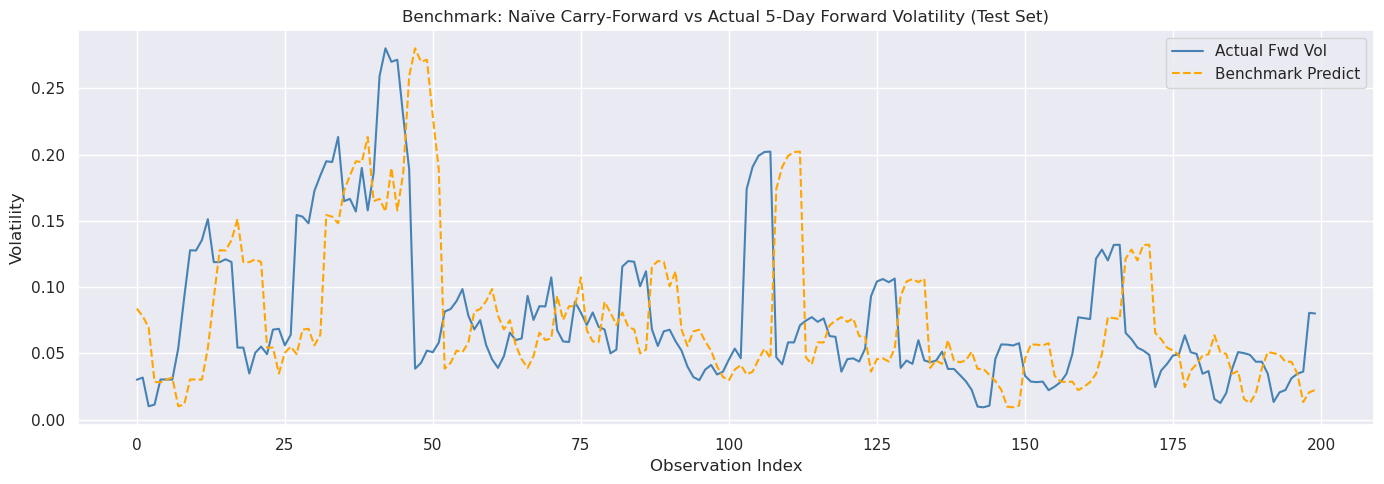

In [3]:
# ==============================================================================
# 2. Benchmark Model — Naïve Volatility Carry-Forward
# ==============================================================================
# Prediction rule: ŷ = Hist_Vol_5d  (no fitting required)
# Rationale: Volatility is mean-reverting but highly autocorrelated at short
# horizons, so the most recent observed vol is a strong naive predictor.

print("=" * 60)
print("BENCHMARK MODEL: Naïve Historical Volatility Carry-Forward")
print("=" * 60)

# Validation performance
bench_val_preds  = X_val['Hist_Vol_5d'].values
bench_val_rmse   = np.sqrt(mean_squared_error(y_val, bench_val_preds))
bench_val_mae    = mean_absolute_error(y_val, bench_val_preds)
bench_val_r2     = r2_score(y_val, bench_val_preds)

# Test performance
bench_test_preds = X_test['Hist_Vol_5d'].values
bench_test_rmse  = np.sqrt(mean_squared_error(y_test, bench_test_preds))
bench_test_mae   = mean_absolute_error(y_test, bench_test_preds)
bench_test_r2    = r2_score(y_test, bench_test_preds)

print(f"\n[Validation]")
print(f"  RMSE : {bench_val_rmse:.6f}")
print(f"  MAE  : {bench_val_mae:.6f}")
print(f"  R²   : {bench_val_r2:.4f}")

print(f"\n[Test]")
print(f"  RMSE : {bench_test_rmse:.6f}")
print(f"  MAE  : {bench_test_mae:.6f}")
print(f"  R²   : {bench_test_r2:.4f}")

# Visual: Benchmark predictions vs actuals on test set (first 200 points)
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.values[:200],          label='Actual Fwd Vol',    color='steelblue', lw=1.5)
ax.plot(bench_test_preds[:200],       label='Benchmark Predict', color='orange',    lw=1.5, linestyle='--')
ax.set_title('Benchmark: Naïve Carry-Forward vs Actual 5-Day Forward Volatility (Test Set)')
ax.set_xlabel('Observation Index')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()

## ML Model: XGBoost via SageMaker Estimator

We use SageMaker's managed **XGBoost container** so the training job runs on a
dedicated instance — not the notebook kernel — and produces an S3 model artifact
ready for deployment.

In [4]:
# ==============================================================================
# 3a. Uploading Train / Validation CSVs to S3 for SageMaker Training Job
# ==============================================================================
# SageMaker's built-in XGBoost container expects:
#   - CSV with NO header
#   - Target column FIRST, then features

MODEL_DATA_PREFIX = f"{PREFIX}/model-data"

def df_to_libsvm_s3(X: pd.DataFrame, y: pd.Series, split_name: str) -> str:
    """Combines target + features, drops header, uploads CSV to S3."""
    combined = pd.concat([y.reset_index(drop=True),
                          X.reset_index(drop=True)], axis=1)
    csv_buffer = io.StringIO()
    combined.to_csv(csv_buffer, index=False, header=False)
    key = f"{MODEL_DATA_PREFIX}/{split_name}/data.csv"
    s3_client.put_object(Bucket=S3_BUCKET, Key=key, Body=csv_buffer.getvalue())
    s3_uri = f"s3://{S3_BUCKET}/{key}"
    print(f"Uploaded {split_name} -> {s3_uri}")
    return f"s3://{S3_BUCKET}/{MODEL_DATA_PREFIX}/{split_name}/"


print("Preparing and uploading training data for SageMaker...")
train_s3_uri = df_to_libsvm_s3(X_train, y_train, "train")
val_s3_uri   = df_to_libsvm_s3(X_val,   y_val,   "validation")

Preparing and uploading training data for SageMaker...


Uploaded train -> s3://sagemaker-us-east-1-025891565789/quantamental-platform/model-data/train/data.csv
Uploaded validation -> s3://sagemaker-us-east-1-025891565789/quantamental-platform/model-data/validation/data.csv


In [13]:
from sagemaker.estimator import Estimator
from sagemaker import image_uris
import time

# 1. Fetch the exact URI for the built-in XGBoost container
xgboost_container = image_uris.retrieve(
    framework="xgboost",
    region=sagemaker_session.boto_region_name,
    version="1.7-1"
)

# 2. Use the generic Estimator (This bypasses the SDK serialization bug)
xgb_estimator = Estimator(
    image_uri          = xgboost_container,
    instance_type      = "ml.m5.large",
    instance_count     = 1,
    role               = sagemaker_role,
    sagemaker_session  = sagemaker_session,
    output_path        = f"s3://{S3_BUCKET}/{PREFIX}/model-artifacts/",
    base_job_name      = "quantamental-xgb",
    hyperparameters    = {
        "objective"        : "reg:squarederror",
        "eval_metric"      : "rmse",
        "num_round"        : "300",   # Safe to use standard strings here!
        "max_depth"        : "6",
        "eta"              : "0.05",
        "subsample"        : "0.8",
        "colsample_bytree" : "0.8",
        "alpha"            : "0.1",
        "lambda"           : "1.0",
    }
)

JOB_NAME = f"quantamental-xgb-{int(time.time())}"

train_input = TrainingInput(train_s3_uri, content_type="text/csv")
val_input   = TrainingInput(val_s3_uri,   content_type="text/csv")

print(f"Launching SageMaker Training Job: {JOB_NAME}")

xgb_estimator.fit(
    inputs   = {"train": train_input, "validation": val_input},
    job_name = JOB_NAME,
    wait     = True,
    logs     = True
)

MODEL_ARTIFACT_URI = xgb_estimator.model_data
print(f"\nTraining Complete! Model artifact: {MODEL_ARTIFACT_URI}")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


INFO:sagemaker:Creating training-job with name: quantamental-xgb-1780829190


Launching SageMaker Training Job: quantamental-xgb-1780829190


2026-06-07 10:46:32 Starting - Starting the training job.

...

.


2026-06-07 10:49:01 Training - Training image download completed. Training in progress..

/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-07 10:49:05.522 ip-10-2-222-134.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-06-07 10:49:05.582 ip-10-2-222-134.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-06-07:10:49:05:INFO] Imported framework sagemaker_xgboost_container.training
[2026-06-07:10:49:05:INFO] Failed to parse hyperparameter eval_metric value rmse to Json.
Returning the value itself
[2026-06-07:10:49:05:INFO] Failed to parse hyperparameter objective value reg:squarederror to Json.
Returning the value itself
[2026-06-07:10:49:05:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-07:10:49:05:INFO] R


2026-06-07 10:49:29 Uploading - Uploading generated training model
2026-06-07 10:49:29 Completed - Training job completed


Training seconds: 140
Billable seconds: 140

Training Complete! Model artifact: s3://sagemaker-us-east-1-025891565789/quantamental-platform/model-artifacts/quantamental-xgb-1780829190/output/model.tar.gz


## Evaluation: XGBoost vs Benchmark

In [14]:
# ==============================================================================
# 4a. Loading trained model locally for evaluation
# ==============================================================================

import xgboost as xgb

# Parsing bucket/key from artifact URI
artifact_parts = MODEL_ARTIFACT_URI.replace("s3://", "").split("/", 1)
artifact_bucket, artifact_key = artifact_parts[0], artifact_parts[1]

local_tar  = "/tmp/model.tar.gz"
local_dir  = "/tmp/xgb_model/"
os.makedirs(local_dir, exist_ok=True)

print("Downloading model artifact from S3...")
s3_client.download_file(artifact_bucket, artifact_key, local_tar)

with tarfile.open(local_tar) as tar:
    tar.extractall(path=local_dir)

# SageMaker managed XGBoost saves the model as 'xgboost-model'
model_path = os.path.join(local_dir, "xgboost-model")
booster    = xgb.Booster()
booster.load_model(model_path)

# Predicting on test set
dtest     = xgb.DMatrix(X_test.values, label=y_test.values,
                         feature_names=FEATURE_COLS)
xgb_preds = booster.predict(dtest)

xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_test_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_test_r2   = r2_score(y_test, xgb_preds)

print(f"\n[XGBoost — Test Set]")
print(f"  RMSE : {xgb_test_rmse:.6f}")
print(f"  MAE  : {xgb_test_mae:.6f}")
print(f"  R²   : {xgb_test_r2:.4f}")


[XGBoost — Test Set]
  RMSE : 0.023999
  MAE  : 0.012891
  R²   : 0.4634


/tmp/ipykernel_1015/523254390.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_dir)


In [15]:
# ==============================================================================
# 4b. Side-by-Side Comparison Table
# ==============================================================================

results = pd.DataFrame({
    'Model'     : ['Benchmark (Naïve Carry-Forward)', 'XGBoost Regressor'],
    'RMSE'      : [bench_test_rmse, xgb_test_rmse],
    'MAE'       : [bench_test_mae,  xgb_test_mae],
    'R²'        : [bench_test_r2,   xgb_test_r2],
})

results['RMSE Δ vs Bench'] = results['RMSE'] - bench_test_rmse
results['R² Δ vs Bench']   = results['R²']   - bench_test_r2

print("=" * 70)
print("MODEL COMPARISON — Test Set Results")
print("=" * 70)
print(results.to_string(index=False, float_format='%.6f'))

rmse_improvement = (bench_test_rmse - xgb_test_rmse) / bench_test_rmse * 100
print(f"\nXGBoost RMSE improvement over benchmark: {rmse_improvement:.2f}%")

MODEL COMPARISON — Test Set Results
                          Model     RMSE      MAE       R²  RMSE Δ vs Bench  R² Δ vs Bench
Benchmark (Naïve Carry-Forward) 0.027601 0.013096 0.290281         0.000000       0.000000
              XGBoost Regressor 0.023999 0.012891 0.463443        -0.003602       0.173163

XGBoost RMSE improvement over benchmark: 13.05%


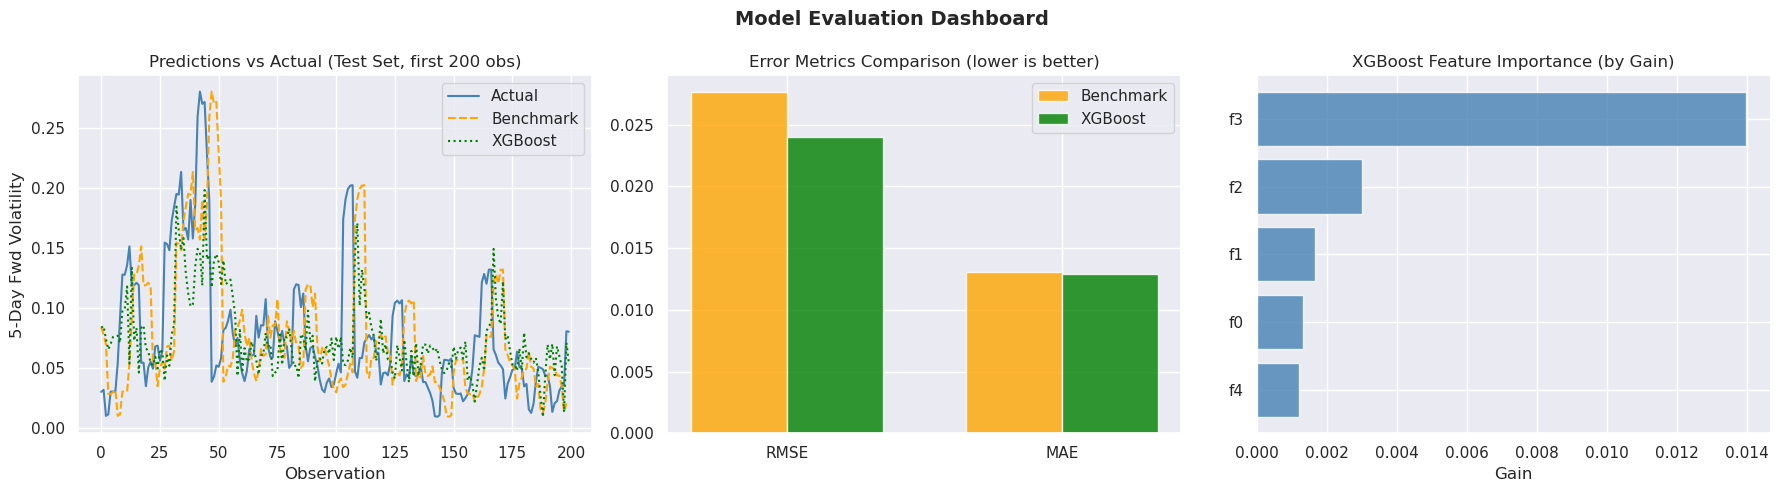


Evaluation complete.


In [16]:
# ==============================================================================
# 4c. Visualisations
# ==============================================================================

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Predictions vs Actuals (line, first 200 obs) ---
n = 200
axes[0].plot(y_test.values[:n],    label='Actual',    color='steelblue', lw=1.5)
axes[0].plot(bench_test_preds[:n], label='Benchmark', color='orange',    lw=1.5, linestyle='--')
axes[0].plot(xgb_preds[:n],        label='XGBoost',   color='green',     lw=1.5, linestyle=':')
axes[0].set_title('Predictions vs Actual (Test Set, first 200 obs)')
axes[0].set_xlabel('Observation')
axes[0].set_ylabel('5-Day Fwd Volatility')
axes[0].legend()

# --- Plot 2: Metric Bar Chart ---
metrics = ['RMSE', 'MAE']
bench_vals = [bench_test_rmse, bench_test_mae]
xgb_vals   = [xgb_test_rmse,  xgb_test_mae]
x = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, bench_vals, width, label='Benchmark', color='orange', alpha=0.8)
axes[1].bar(x + width/2, xgb_vals,   width, label='XGBoost',   color='green',  alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Error Metrics Comparison (lower is better)')
axes[1].legend()

# --- Plot 3: XGBoost Feature Importance ---
importance = booster.get_score(importance_type='gain')
imp_df     = pd.DataFrame({'Feature': list(importance.keys()),
                            'Gain': list(importance.values())})
imp_df     = imp_df.sort_values('Gain', ascending=True)
axes[2].barh(imp_df['Feature'], imp_df['Gain'], color='steelblue', alpha=0.8)
axes[2].set_title('XGBoost Feature Importance (by Gain)')
axes[2].set_xlabel('Gain')

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEvaluation complete.")

## Deployment: Real-Time SageMaker Endpoint

We deploy the XGBoost model to a **persistent real-time endpoint** using
`ml.m5.large`. The endpoint accepts CSV rows and returns predicted volatility
values synchronously — suitable for a production risk dashboard.

In [17]:
# ==============================================================================
# 5a. Deploying XGBoost Model to Real-Time Endpoint
# ==============================================================================

ENDPOINT_NAME = "quantamental-vol-predictor-v1"

print(f"Deploying model to endpoint: {ENDPOINT_NAME}")

predictor = xgb_estimator.deploy(
    initial_instance_count = 1,
    instance_type          = "ml.m5.large",
    endpoint_name          = ENDPOINT_NAME,
    serializer             = sagemaker.serializers.CSVSerializer(),
    deserializer           = sagemaker.deserializers.JSONDeserializer(),
)

print(f"\nEndpoint '{ENDPOINT_NAME}' is InService and ready for inference!")

INFO:sagemaker:Creating model with name: quantamental-xgb-2026-06-07-10-51-43-316


Deploying model to endpoint: quantamental-vol-predictor-v1


INFO:sagemaker:Creating endpoint-config with name quantamental-vol-predictor-v1


INFO:sagemaker:Creating endpoint with name quantamental-vol-predictor-v1


-

...

-

-

-

!


Endpoint 'quantamental-vol-predictor-v1' is InService and ready for inference!


In [20]:
# ==============================================================================
# 5b. Sample Real-Time Inference
# ==============================================================================
# Sending 5 test-set rows to the live endpoint and comparing predictions to actuals.

sample_X = X_test.iloc[:5].values
sample_y = y_test.iloc[:5].values

print("Sending sample inference request to endpoint...\n")

# The CSV serializer converts the numpy array to a CSV string automatically
raw_response = predictor.predict(sample_X)

if isinstance(raw_response, dict):
    preds_list = raw_response.get("predictions", raw_response)
    
    clean_preds = []
    for p in preds_list:
        if isinstance(p, dict):
            clean_preds.append(float(p.get("score", 0.0)))
        elif isinstance(p, list):
            clean_preds.append(float(p[0]))
        else:
            clean_preds.append(float(p))
            
    endpoint_preds = np.array(clean_preds)
else:
    # Fallback just in case it returns a flat list natively
    endpoint_preds = np.array(raw_response)

print("Sample Inference Results:")
print(f"{'Index':<8} {'Actual Fwd Vol':<20} {'Endpoint Prediction':<22} {'Abs Error':<12}")
print("-" * 62)

for i, (actual, pred) in enumerate(zip(sample_y, endpoint_preds)):
    print(f"{i:<8} {actual:<20.6f} {pred:<22.6f} {abs(actual - pred):<12.6f}")

print("\nReal-time endpoint inference successful!")

Sending sample inference request to endpoint...

Sample Inference Results:
Index    Actual Fwd Vol       Endpoint Prediction    Abs Error   
--------------------------------------------------------------
0        0.030190             0.083602               0.053412    
1        0.031824             0.085009               0.053185    
2        0.010191             0.074057               0.063866    
3        0.011421             0.065497               0.054076    
4        0.030372             0.070110               0.039738    

Real-time endpoint inference successful!


In [23]:
# ==============================================================================
# 5c. (IMPORTANT) Deleting Endpoint & Monitors to avoid ongoing charges
# ==============================================================================
import boto3

print(f"Deleting endpoint '{predictor.endpoint_name}' to stop billing...")
predictor.delete_endpoint(delete_endpoint_config=True)
print("Endpoint deleted. Model artifact is safely stored in S3.")

# Check for and delete any orphaned Model Monitor schedules
sm_client = boto3.client('sagemaker')
print("\nChecking for active Model Monitor schedules...")
schedules = sm_client.list_monitoring_schedules()['MonitoringScheduleSummaries']

if not schedules:
    print("No active schedules found. You are safe!")
else:
    for schedule in schedules:
        schedule_name = schedule['MonitoringScheduleName']
        print(f"Deleting orphaned schedule: {schedule_name}...")
        sm_client.delete_monitoring_schedule(
            MonitoringScheduleName=schedule_name
        )
    print("All schedules deleted successfully.")


Checking for active Model Monitor schedules...
No active schedules found. You are safe!
